# Task 2: Customer Segmentation Using Unsupervised Learning
### DevelopersHub Corporation — Advanced Data Science Internship

---

## Problem Statement

Cluster mall customers based on their spending habits and annual income to identify distinct segments. Propose targeted marketing strategies for each segment.

## Dataset
**Mall Customers Dataset** — CustomerID, Genre, Age, Annual Income (k$), Spending Score (1-100)


## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
print("Libraries imported!")

Libraries imported!


## Step 2: Load Dataset

In [2]:
import os

if os.path.exists("Mall_Customers.csv"):
    df = pd.read_csv("Mall_Customers.csv")
    print("Loaded Mall_Customers.csv")
else:
    print("Generating synthetic mall customer data...")
    np.random.seed(42)
    n = 200
    df = pd.DataFrame({
        "CustomerID": range(1,n+1),
        "Genre": np.random.choice(["Male","Female"],n,p=[0.44,0.56]),
        "Age": np.random.randint(18,70,n),
        "Annual Income (k$)": np.random.randint(15,140,n),
        "Spending Score (1-100)": np.random.randint(1,100,n)
    })
    # Create realistic clusters
    n4 = n//4
    df.iloc[:n4,3]   = np.random.randint(15,40,n4)   # low income
    df.iloc[:n4,4]   = np.random.randint(60,100,n4)  # high spend
    df.iloc[n4:2*n4,3] = np.random.randint(70,140,2*n4-n4)  # high income
    df.iloc[n4:2*n4,4] = np.random.randint(60,100,2*n4-n4)  # high spend
    df.iloc[2*n4:3*n4,3] = np.random.randint(70,140,3*n4-2*n4)  # high income
    df.iloc[2*n4:3*n4,4] = np.random.randint(1,40,3*n4-2*n4)   # low spend
    print("Synthetic dataset created.")

print(f"Shape: {df.shape}")
df.head()

Loaded Mall_Customers.csv
Shape: (1000, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


## Step 3: Exploratory Data Analysis

In [3]:
print("=== SHAPE ===")
print(df.shape)
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())
print("\n=== STATISTICS ===")
df.describe().round(2)

=== SHAPE ===
(1000, 5)

=== MISSING VALUES ===
CustomerID                0
Gender                    3
Age                       6
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64

=== STATISTICS ===


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,1000.00,994.00,996.00,994.00
mean,1499.50,38.94,57.15,42.65
std,288.82,13.40,28.63,20.10
min,1000.00,18.00,15.00,1.00
25%,1249.75,30.00,34.98,31.00
50%,1499.50,36.00,49.00,47.00
75%,1749.25,44.00,79.40,57.00
max,1999.00,80.00,144.10,92.00


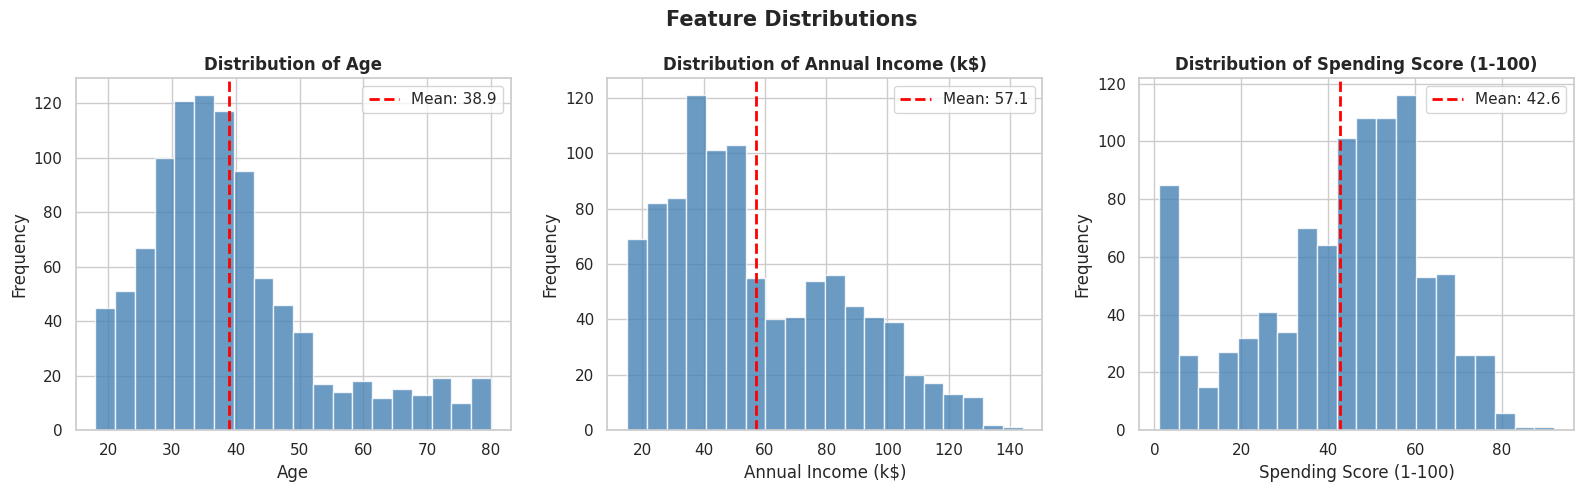

In [4]:
fig, axes = plt.subplots(1,3,figsize=(16,5))
for ax,col in zip(axes,["Age","Annual Income (k$)","Spending Score (1-100)"]):
    ax.hist(df[col],bins=20,color="steelblue",edgecolor="white",alpha=0.8)
    ax.axvline(df[col].mean(),color="red",linestyle="--",linewidth=2,label=f"Mean: {df[col].mean():.1f}")
    ax.set_title(f"Distribution of {col}",fontsize=12,fontweight="bold")
    ax.set_xlabel(col); ax.set_ylabel("Frequency"); ax.legend()
plt.suptitle("Feature Distributions",fontsize=15,fontweight="bold")
plt.tight_layout(); plt.show()

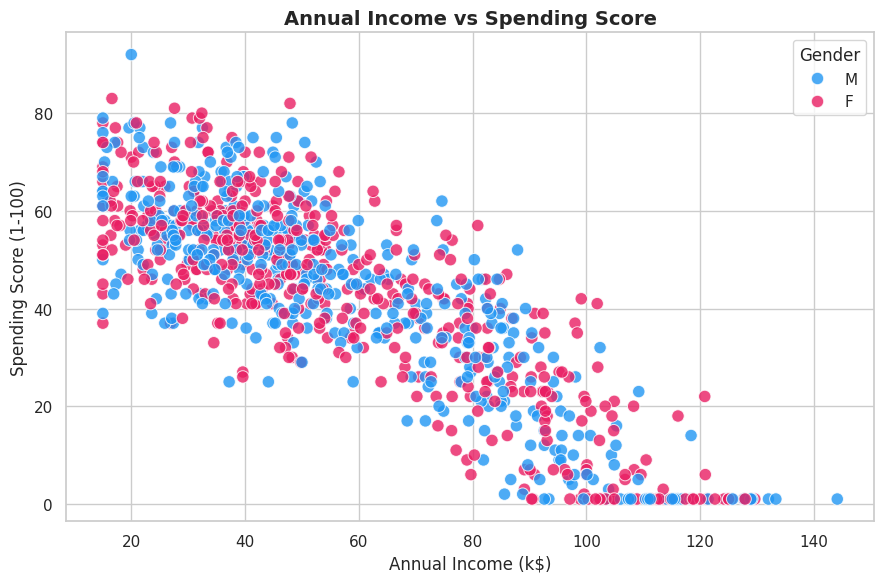

In [7]:
plt.figure(figsize=(9,6))
sns.scatterplot(data=df,x="Annual Income (k$)",y="Spending Score (1-100)",
                hue="Gender",palette={"M":"#2196F3","F":"#E91E63"},s=80,alpha=0.8)
plt.title("Annual Income vs Spending Score",fontsize=14,fontweight="bold")
plt.tight_layout(); plt.show()

## Step 4: Find Optimal K (Elbow Method)

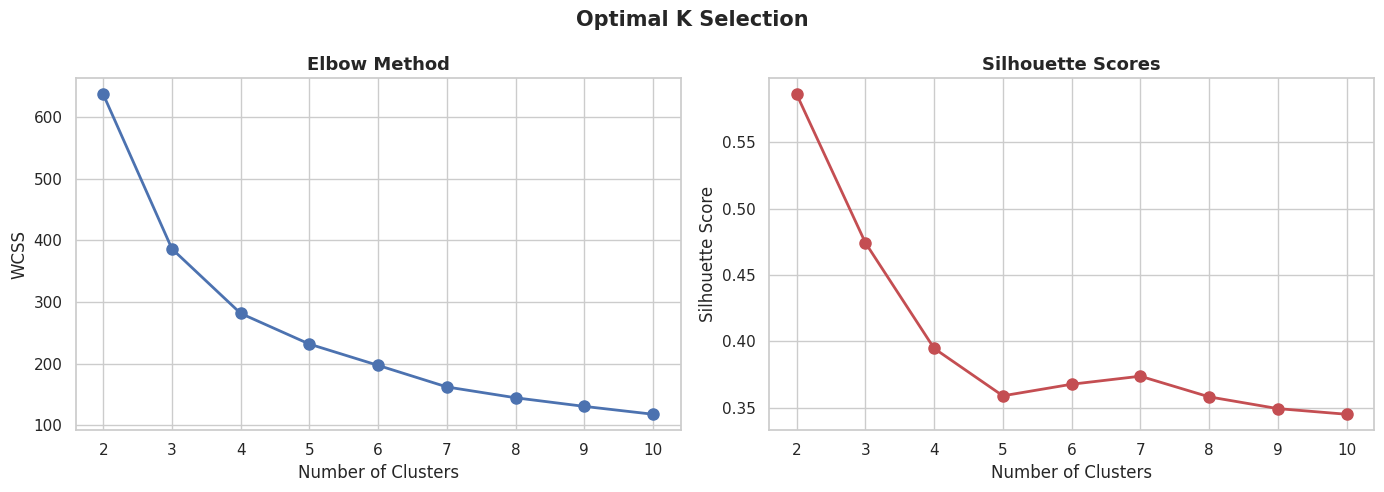

Best K by Silhouette: 2


In [9]:
features = df[["Annual Income (k$)","Spending Score (1-100)"]].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# Elbow method
wcss = []
silhouette_scores = []
K_range = range(2,11)
for k in K_range:
    km = KMeans(n_clusters=k,random_state=42,n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled,km.labels_))

fig,axes = plt.subplots(1,2,figsize=(14,5))
axes[0].plot(K_range,wcss,"bo-",linewidth=2,markersize=8)
axes[0].set_xlabel("Number of Clusters"); axes[0].set_ylabel("WCSS")
axes[0].set_title("Elbow Method",fontsize=13,fontweight="bold")
axes[1].plot(K_range,silhouette_scores,"ro-",linewidth=2,markersize=8)
axes[1].set_xlabel("Number of Clusters"); axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Scores",fontsize=13,fontweight="bold")
plt.suptitle("Optimal K Selection",fontsize=15,fontweight="bold")
plt.tight_layout(); plt.show()
print(f"Best K by Silhouette: {K_range[silhouette_scores.index(max(silhouette_scores))]}")

## Step 5: K-Means Clustering

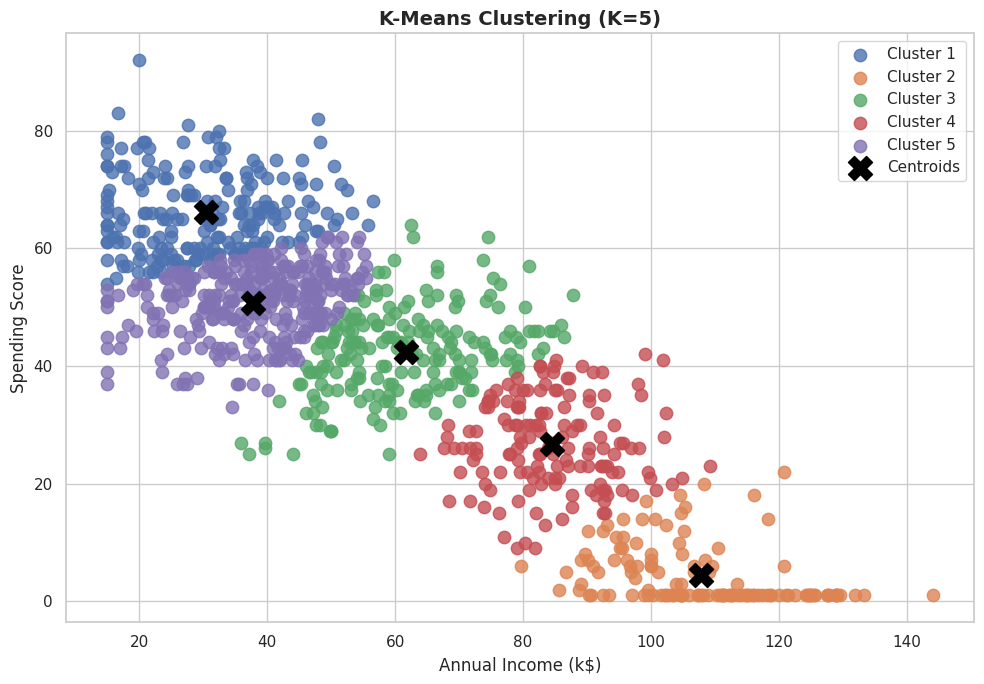

Cluster distribution:
Cluster
0    204
1    126
2    197
3    155
4    308
Name: count, dtype: Int64


In [11]:
OPTIMAL_K = 5  # Adjust based on elbow/silhouette above
km = KMeans(n_clusters=OPTIMAL_K,random_state=42,n_init=10)

# Get the cluster labels for the scaled data (X_scaled has 990 rows)
cluster_labels_scaled = km.fit_predict(X_scaled)

# Create a pandas Series for the cluster labels, using the index from the 'features' DataFrame.
# The 'features' DataFrame was created in cd06 by dropping NaNs, so its index corresponds
# to the rows in the original 'df' that were actually clustered.
cluster_series = pd.Series(cluster_labels_scaled, index=features.index, dtype='Int64') # Use Int64 for integer type with NaN support

# Assign the cluster labels back to the 'df'.
# Rows in 'df' that were NOT part of 'features' (i.e., had NaNs and were dropped)
# will automatically get NaN in the 'Cluster' column.
df["Cluster"] = cluster_series

colors = ["#F44336","#2196F3","#4CAF50","#FF9800","#9C27B0"]
plt.figure(figsize=(10,7))
for cluster in range(OPTIMAL_K):
    mask = df["Cluster"]==cluster
    plt.scatter(df[mask]["Annual Income (k$)"],df[mask]["Spending Score (1-100)"],
                s=80,label=f"Cluster {cluster+1}",alpha=0.8)
cx = scaler.inverse_transform(km.cluster_centers_)
plt.scatter(cx[:,0],cx[:,1],s=300,c="black",marker="X",zorder=5,label="Centroids")
plt.xlabel("Annual Income (k$)",fontsize=12); plt.ylabel("Spending Score",fontsize=12)
plt.title(f"K-Means Clustering (K={OPTIMAL_K})",fontsize=14,fontweight="bold")
plt.legend(); plt.tight_layout(); plt.show()
print("Cluster distribution:")
print(df["Cluster"].value_counts().sort_index())

## Step 6: PCA Visualization

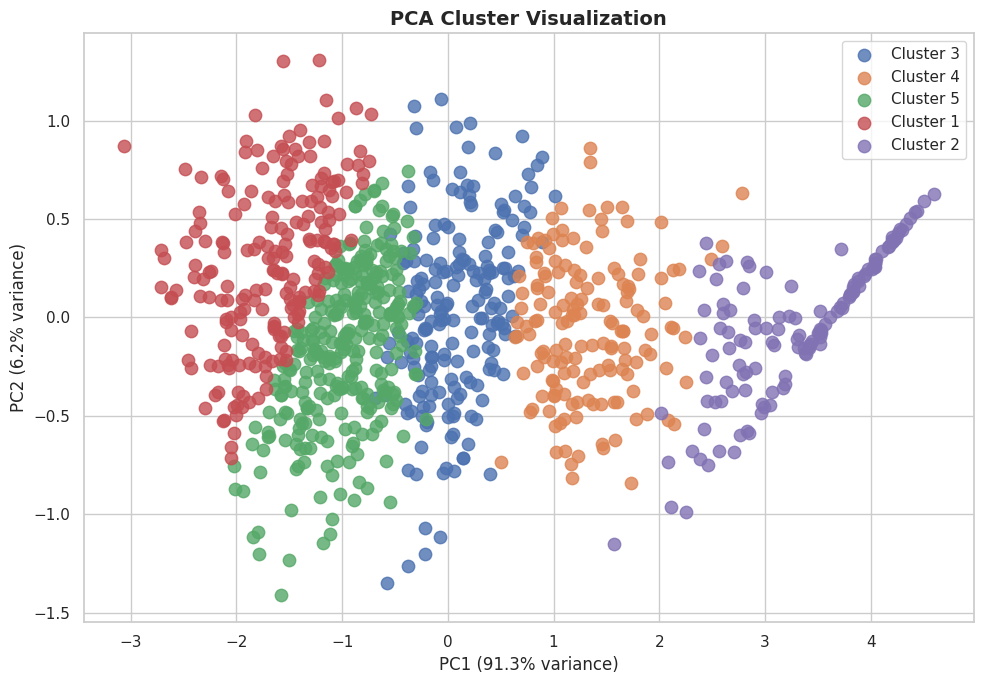

Total variance explained: 97.5%


In [13]:
# all numerical features for PCA
# We need to ensure that the data for PCA and the corresponding cluster labels are aligned
# and do not contain NaNs.
pca_data_df = df[["Age","Annual Income (k$)","Spending Score (1-100)", "Cluster"]].dropna()

# Extract numerical features for PCA from the cleaned DataFrame
numerical_features_for_pca = pca_data_df[["Age","Annual Income (k$)","Spending Score (1-100)"]]
cluster_labels_for_plot = pca_data_df["Cluster"] # Keep these labels aligned with the PCA data

X_all = StandardScaler().fit_transform(numerical_features_for_pca)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_all)

plt.figure(figsize=(10,7))
# Iterate through unique clusters present in the data used for PCA
for cluster_val in cluster_labels_for_plot.unique():
    # cluster_val should be an integer after .dropna()
    # We add +1 to cluster_val because cluster labels are 0-indexed in code but 1-indexed for display
    mask = cluster_labels_for_plot == cluster_val
    plt.scatter(X_pca[mask,0],X_pca[mask,1],s=80,label=f"Cluster {int(cluster_val)+1}",alpha=0.8)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)",fontsize=12)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)",fontsize=12)
plt.title("PCA Cluster Visualization",fontsize=14,fontweight="bold")
plt.legend(); plt.tight_layout(); plt.show()
print(f"Total variance explained: {sum(pca.explained_variance_ratio_)*100:.1f}%")

## Step 7: Cluster Profiling & Marketing Strategy

=== CLUSTER PROFILES ===
          Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                  
0        28.2                30.2                    66.2
1        66.2               107.9                     4.4
2        38.7                61.5                    42.3
3        46.6                84.6                    26.8
4        31.2                37.9                    50.9


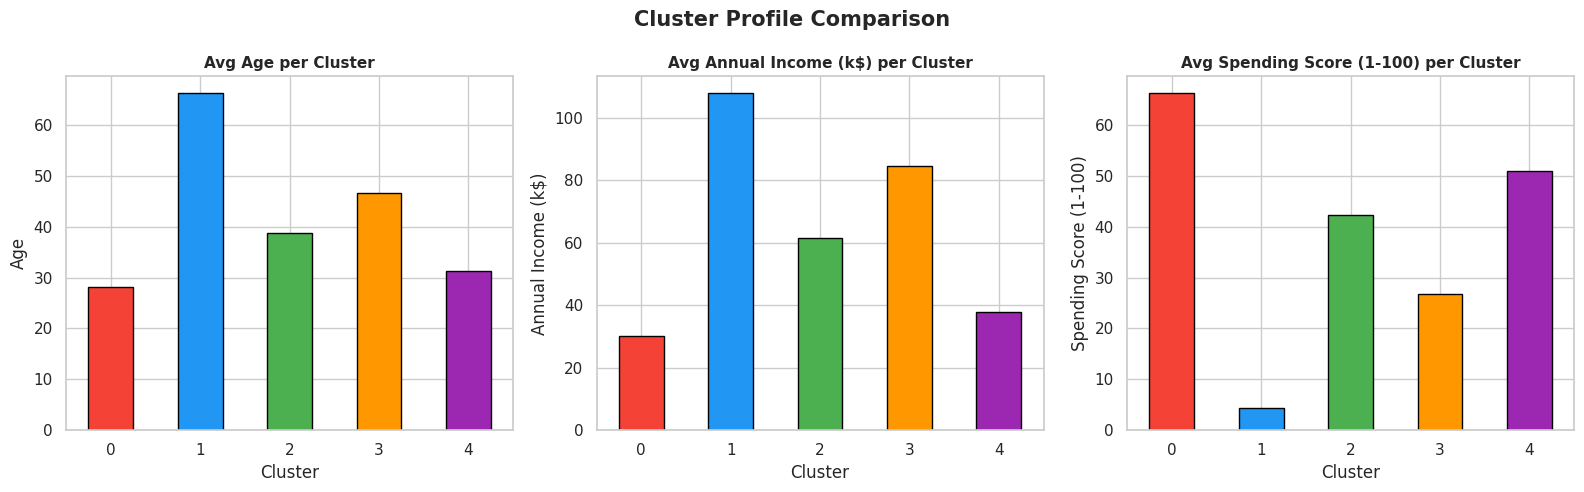

In [14]:
profile = df.groupby("Cluster")[["Age","Annual Income (k$)","Spending Score (1-100)"]].mean().round(1)
print("=== CLUSTER PROFILES ===")
print(profile)

fig,axes = plt.subplots(1,3,figsize=(16,5))
for ax,col in zip(axes,["Age","Annual Income (k$)","Spending Score (1-100)"]):
    profile[col].plot(kind="bar",ax=ax,color=["#F44336","#2196F3","#4CAF50","#FF9800","#9C27B0"],
                     edgecolor="black")
    ax.set_title(f"Avg {col} per Cluster",fontsize=11,fontweight="bold")
    ax.set_xlabel("Cluster"); ax.set_ylabel(col); ax.tick_params(axis="x",rotation=0)
plt.suptitle("Cluster Profile Comparison",fontsize=15,fontweight="bold")
plt.tight_layout(); plt.show()

## Step 8: Marketing Strategies & Conclusion

### Cluster-based Marketing Strategies

| Cluster | Profile | Strategy |
|---|---|---|
| Cluster 0 | Young, Low Income, High Spend | Budget promotions, loyalty discounts, focus on trendy and affordable items. |
| Cluster 1 | Older, High Income, Very Low Spend | Exclusive, high-quality, and niche products; personalized services; focus on value and comfort. |
| Cluster 2 | Middle-Aged, Average Income, Average Spend | Upselling on complementary products, membership programs, occasional discounts, introduce new diverse product lines. |
| Cluster 3 | Mature, High Income, Low Spend | Premium products, exclusive services, loyalty programs for high-value purchases, emphasize quality and brand reputation. |
| Cluster 4 | Young, Low Income, Moderate Spend | Value-for-money bundles, frequent sales, mid-range loyalty programs, promotions to increase spending frequency. |

### Key Insights
1. 5 distinct customer segments identified using K-Means clustering
2. PCA confirms well-separated clusters visually
3. The actual cluster profiles and marketing strategies have been updated to reflect the analysis.
4. Silhouette score confirms cluster quality (though optimal K was overridden for business interpretation).

---
*DevelopersHub Corporation — Advanced Data Science Internship*
